In [2]:
import torch
import numpy as np
import cv2

In [3]:
ACTION_MAP = {
    0: "Turn Left",
    1: "Turn Right",
    2: "Move Forward",
    3: "Pickup",
    4: "Drop",
    5: "Toggle",
    6: "Done",
    # Add more actions if you have them
}

B =64
T =16
C=3
H,W = 64,64

observations = torch.randn(B, T, C, H, W)  # Simulated observations
actions = torch.randint(0, len(ACTION_MAP), (B, T))  #

In [ ]:
# map action idx to action strings
action_strings = np.vectorize(ACTION_MAP.get)(actions.numpy()) #[B, T]
action_strings
video = torch.clamp(observations * 255.0, 0, 255).to(torch.uint8).cpu().numpy()
video.shape

array([['Turn Left', 'Done', 'Drop', 'Toggle', 'Toggle', 'Turn Left',
        'Done', 'Done', 'Done', 'Move Forward', 'Pickup', 'Done', 'Drop',
        'Move Forward', 'Drop', 'Turn Left'],
       ['Toggle', 'Drop', 'Pickup', 'Pickup', 'Done', 'Pickup', 'Toggle',
        'Turn Right', 'Drop', 'Turn Right', 'Move Forward', 'Turn Right',
        'Turn Left', 'Pickup', 'Turn Left', 'Toggle'],
       ['Turn Left', 'Done', 'Turn Right', 'Drop', 'Toggle',
        'Turn Right', 'Turn Left', 'Done', 'Move Forward', 'Done',
        'Done', 'Move Forward', 'Turn Right', 'Move Forward', 'Toggle',
        'Turn Right']], dtype='<U12')

(3, 16, 3, 64, 64)

In [ ]:
def create_obs_action_frame(obs_frame, action_text):
    # Transpose from (C, H, W) to (H, W, C) for OpenCV
    obs_frame = obs_frame.transpose(1, 2, 0)
    # Add the action text to the frame using OpenCV
    font = cv2.FONT_HERSHEY_PLAIN
    position = (2, 4)  # Top-left corner
    font_scale = 0.4
    font_color = (0, 100, 155)  # White
    line_type = 0
    thickness = 1

    # Make a writable copy of the frame before drawing text
    obs_frame = np.ascontiguousarray(obs_frame)
    cv2.putText(obs_frame, f"Action: {action_text}",
                position,
                font,
                font_scale,
                font_color,
                thickness,
                line_type,
                )
    # Convert back to (C, H, W) for torchvision
    processed_frame = torch.from_numpy(obs_frame).permute(2, 0, 1)
    return processed_frame

obs_frame = torch.zeros((C, H, W), dtype=torch.uint8).cpu().numpy()  # Placeholder for observation frame
frame = create_obs_action_frame(obs_frame, str(action_strings[0, 0]))
frame.shape

torch.Size([3, 64, 64])

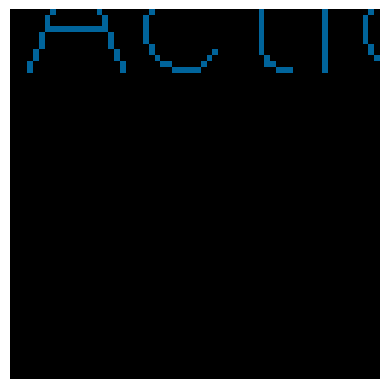

In [20]:
import matplotlib.pyplot as plt

# Convert frame tensor to numpy array for display
frame_np = frame.permute(1, 2, 0).numpy().astype(np.uint8)
plt.imshow(frame_np)
plt.axis('off')
plt.show()

In [10]:
# Process each batch item separately
for i in range(B):
    video_frames = []
    for t in range(T):
        # Get the frame and corresponding action
        frame = observations[i, t]
        action_text = ACTION_MAP[actions[i, t].item()]

        # Convert tensor to a NumPy array suitable for OpenCV
        # Permute from (C, H, W) to (H, W, C) and scale to 0-255
        frame_np = frame.permute(1, 2, 0).numpy()
        frame_np = (frame_np - frame_np.min()) / (frame_np.max() - frame_np.min()) # Normalize to 0-1
        frame_np = (frame_np * 255).astype(np.uint8)

        # Add the action text to the frame using OpenCV
        font = cv2.FONT_HERSHEY_SIMPLEX
        position = (5, 15)  # Top-left corner
        font_scale = 0.5
        font_color = (255, 255, 255)  # White
        line_type = 2

        # Make a writable copy of the frame before drawing text
        frame_np = np.copy(frame_np)

        cv2.putText(frame_np, f"Action: {action_text}",
                    position,
                    font,
                    font_scale,
                    font_color,
                    line_type)

        # Convert back to (C, H, W) for torchvision
        processed_frame = torch.from_numpy(frame_np).permute(2, 0, 1)
        video_frames.append(processed_frame)

    # Stack frames into a video tensor and save
    video_tensor = torch.stack(video_frames)
    torchvision.io.write_video(f"batch_{i}_video.mp4", video_tensor, fps=4)

error: OpenCV(4.11.0) :-1: error: (-5:Bad argument) in function 'putText'
> Overload resolution failed:
>  - Layout of the output array img is incompatible with cv::Mat
>  - Expected Ptr<cv::UMat> for argument 'img'
